In [1]:
import pandas as pd

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

column_names = [
    "Pregnancies",
    "Glucose",
    "Blood pressure",
    "Skin thickness",
    "Insulin",
    "Body mass index",
    "Diabetes pedigree function",
    "Age",
    "Outcome",
]

pid_data = pd.read_csv(
    url,
    header=None,
    names=column_names,
)

# Display the first few rows of data
print(pid_data.head())

   Pregnancies  Glucose  Blood pressure  Skin thickness  Insulin  \
0            6      148              72              35        0   
1            1       85              66              29        0   
2            8      183              64               0        0   
3            1       89              66              23       94   
4            0      137              40              35      168   

   Body mass index  Diabetes pedigree function  Age  Outcome  
0             33.6                       0.627   50        1  
1             26.6                       0.351   31        0  
2             23.3                       0.672   32        1  
3             28.1                       0.167   21        0  
4             43.1                       2.288   33        1  


Matplotlib is building the font cache; this may take a moment.


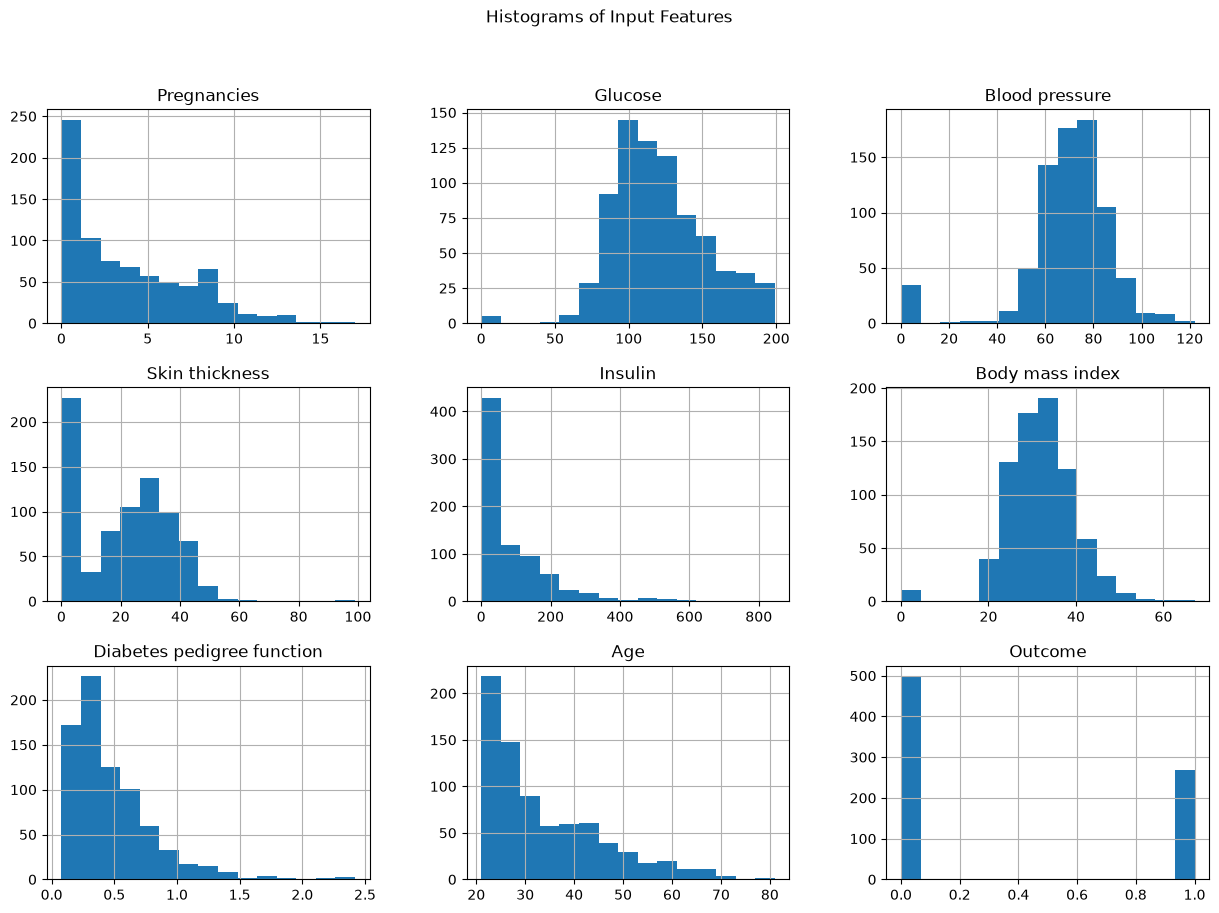

In [3]:
import matplotlib.pyplot as plt

# Plot histograms for each feature
pid_data.hist(bins=15, figsize=(15, 10))
plt.suptitle("Histograms of Input Features")
plt.show()

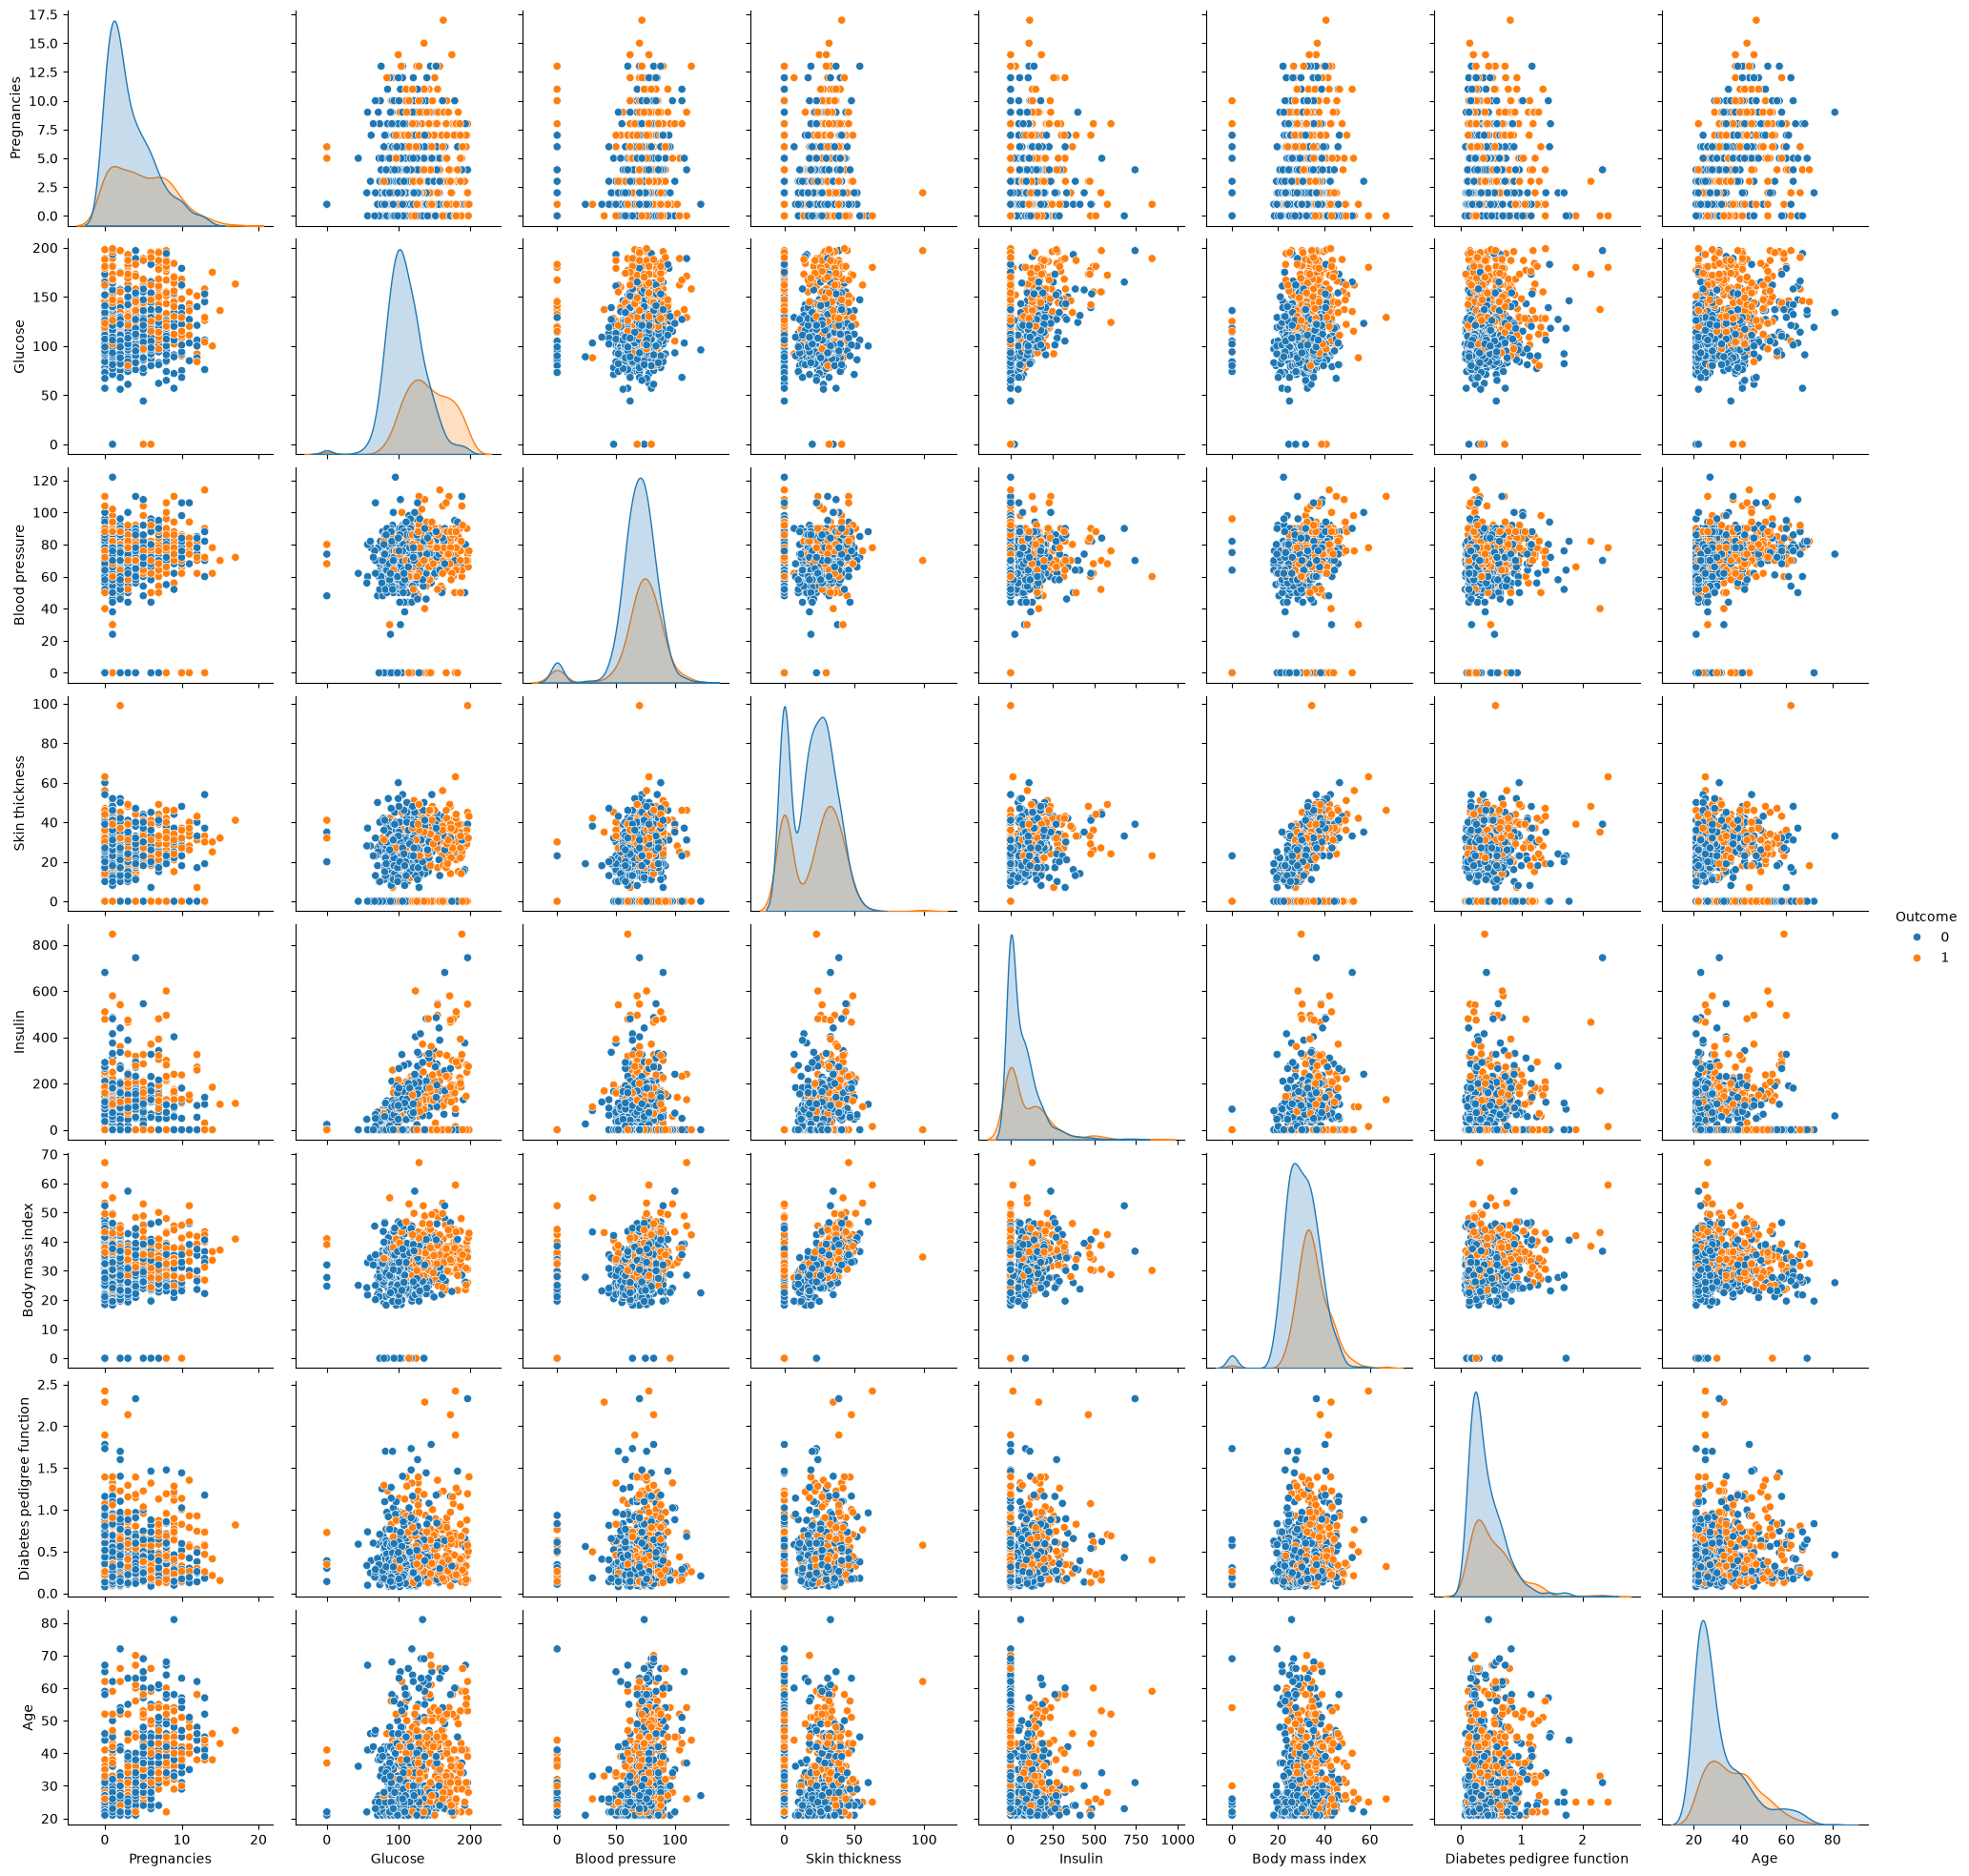

In [4]:
import seaborn as sns

sns.pairplot(pid_data, hue="Outcome")
plt.suptitle("Pairwise Relationships of Features"
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X = pid_data.drop("Outcome", axis=1)
Y = pid_data["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [21]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

dtc_pred = dtc.predict(X_test)

accuracy = accuracy_score(y_test, dtc_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.77


In [23]:
import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/Cellar/graphviz" 

from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(dtc, out_file=None, feature_names=X.columns, class_names=["No Diabetes", "Diabetes"], filled=True, rounded=True, special_characters=True)
graph=graphviz.Source(dot_data)
graph.render("decision_tree")
graph.view()

'decision_tree.pdf'

In [26]:
from sklearn.tree import DecisionTreeClassifier, export_text

tree_structure = export_text(dtc, feature_names=list(X.columns))
print("Decision Tree Structure:\n", tree_structure)

feature_importances = dtc.feature_importances_
feature_importance_summary = sorted(zip(X.columns, feature_importances), key=lambda x: x[1], reverse=True)

print("\nFeature Importances:")
for feature, importance in feature_importance_summary:
    print(f"{feature} : {importance:.4f}")

Decision Tree Structure:
 |--- Glucose <= 127.50
|   |--- Age <= 28.50
|   |   |--- Body mass index <= 30.95
|   |   |   |--- Diabetes pedigree function <= 0.67
|   |   |   |   |--- class: 0
|   |   |   |--- Diabetes pedigree function >  0.67
|   |   |   |   |--- Diabetes pedigree function <= 0.69
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Diabetes pedigree function >  0.69
|   |   |   |   |   |--- class: 0
|   |   |--- Body mass index >  30.95
|   |   |   |--- Blood pressure <= 37.00
|   |   |   |   |--- class: 1
|   |   |   |--- Blood pressure >  37.00
|   |   |   |   |--- Diabetes pedigree function <= 0.50
|   |   |   |   |   |--- Skin thickness <= 8.50
|   |   |   |   |   |   |--- Glucose <= 109.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Glucose >  109.50
|   |   |   |   |   |   |   |--- Glucose <= 123.00
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- Glucose >  123.00
|   |   |   |   |   |   |   |   |--- cl

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 10,20,30],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

dtcp = DecisionTreeClassifier()
grid_search = GridSearchCV(estimator=dtcp, param_grid=param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Score: 0.7426096228175397
